In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

df = pd.read_csv('S02-hw-dataset.csv')

# Первые строки датасета
print("Первые 5 строк датасета:")
print(df.head())
print()

# Информация о столбцах и типах
print("Информация о датасете:")
print(df.info())
print()

# Базовые описательные статистики
print("Описательные статистики:")
print(df.describe())

Первые 5 строк датасета:
   user_id   age country  purchases  revenue
0        1  25.0      FR          7      749
1        2  24.0      RU          5     1115
2        3  52.0      FR          7      399
3        4  31.0      RU          6      654
4        5   NaN      DE          6     1296
Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   user_id    41 non-null     int64  
 1   age        39 non-null     float64
 2   country    41 non-null     object 
 3   purchases  41 non-null     int64  
 4   revenue    41 non-null     int64  
dtypes: float64(1), int64(3), object(1)
memory usage: 1.7+ KB
None
Описательные статистики:
         user_id         age  purchases      revenue
count  41.000000   39.000000  41.000000    41.000000
mean   20.243902   36.512821   4.829268   820.048780
std    11.659289   18.304259   2.710189   613.127

In [7]:
# Доля пропусков в каждом столбце
print("Доля пропусков в каждом столбце:")
print(df.isna().mean())
print()
# Проверка на полностью дублирующие строки
duplicates = df.duplicated()
print(f"Количество полностью дублирующих строк: {duplicates.sum()}")
if duplicates.sum() > 0:
    print("Дублирующие строки:")
    print(df[duplicates])
print()
# Поиск подозрительных случаев
print("Подозрительные случаи:")

# Отрицательные значения в purchases (количество покупок)
negative_purchases = df[df['purchases'] < 0]
print(f"1. Отрицательные значения в purchases: {len(negative_purchases)} записей")
if len(negative_purchases) > 0:
    print(negative_purchases)

# Нереалистичные значения возраста (<0 или >100)
unrealistic_age = df[(df['age'] < 0) | (df['age'] > 100)]
print(f"\n2. Нереалистичные значения возраста: {len(unrealistic_age)} записей")
if len(unrealistic_age) > 0:
    print(unrealistic_age[['user_id', 'age']])

# Нулевой revenue при ненулевых purchases
zero_revenue_with_purchases = df[(df['revenue'] == 0) & (df['purchases'] > 0)]
print(f"\n3. Нулевой revenue при ненулевых purchases: {len(zero_revenue_with_purchases)} записей")
if len(zero_revenue_with_purchases) > 0:
    print(zero_revenue_with_purchases[['user_id', 'purchases', 'revenue']])

# Нулевые purchases при ненулевом revenue
zero_purchases_with_revenue = df[(df['purchases'] == 0) & (df['revenue'] > 0)]
print(f"\n4. Нулевые purchases при ненулевом revenue: {len(zero_purchases_with_revenue)} записей")
if len(zero_purchases_with_revenue) > 0:
    print(zero_purchases_with_revenue[['user_id', 'purchases', 'revenue']])

# Возраст 5 лет (возможно, ошибка ввода)
child_users = df[df['age'] == 5]
print(f"\n5. Пользователи с возрастом 5 лет: {len(child_users)} записей")
if len(child_users) > 0:
    print(child_users[['user_id', 'age', 'purchases', 'revenue']])


# В датасете обнаружено несколько проблем качества данных. Во-первых, есть отрицательное значение в столбце purchases (-1 у пользователя 6), что невозможно для количества покупок. Во-вторых, обнаружен нереалистичный возраст 120 лет у пользователя 6, что маловероятно. Также есть пользователь с возрастом 5 лет, совершивший 8 покупок на сумму 1488, что вызывает сомнения. Найдены случаи нулевого дохода при ненулевых покупках (2 записи) и одна полностью дублирующая строка (user_id=10). Пропуски в данных присутствуют только в столбце age (2 записи).


Доля пропусков в каждом столбце:
user_id      0.000000
age          0.048780
country      0.000000
purchases    0.000000
revenue      0.000000
age_group    0.073171
dtype: float64

Количество полностью дублирующих строк: 1
Дублирующие строки:
    user_id   age country  purchases  revenue age_group
40       10  24.0      RU          7      511     18-30

Подозрительные случаи:
1. Отрицательные значения в purchases: 1 записей
   user_id    age country  purchases  revenue age_group
5        6  120.0      FR         -1      785       NaN

2. Нереалистичные значения возраста: 1 записей
   user_id    age
5        6  120.0

3. Нулевой revenue при ненулевых purchases: 1 записей
    user_id  purchases  revenue
10       11          4        0

4. Нулевые purchases при ненулевом revenue: 0 записей

5. Пользователи с возрастом 5 лет: 1 записей
    user_id  age  purchases  revenue
20       21  5.0          8     1488


In [17]:
# Частоты для категориальной переменной (страна)
print("Распределение пользователей по странам:")
country_counts = df['country'].value_counts()
print(country_counts)
print()

# Группировка по странам с агрегатами
print("Статистики по странам:")
country_stats = df.groupby('country').agg({'age': ['mean', 'median', 'count'],'purchases': ['mean', 'sum'],'revenue': ['mean', 'sum']})
print(country_stats)
print()
df['age_group'] = pd.cut(df['age'],
                         bins=[0, 18, 30, 45, 60, 100],
                         labels=['<18', '18-30', '31-45', '46-60', '>60'])

# Группировка по возрастным группам
print("Статистики по возрастным группам:")
age_group_stats = df.groupby('age_group').agg({'purchases': ['mean', 'count'], 'revenue': ['mean', 'sum']} )
print(age_group_stats)

# Анализ распределения пользователей по странам показывает, что наиболее представлены Россия (RU - 13 записей) и Франция (FR - 12 записей). По среднему возрасту выделяется Германия (DE) с самым высоким показателем (40.8 лет), тогда как в России самый молодой средний возраст (31.2 года). По объему выручки лидирует Германия со средней выручкой 1302 и общей суммой 6507, несмотря на меньшее количество пользователей. Возрастной анализ показывает, что группа 31-45 лет наиболее активна по количеству покупок (в среднем 5.7) и приносит наибольшую выручку (в среднем 921.6).



Распределение пользователей по странам:
country
RU    13
FR    12
US     8
DE     6
CN     2
Name: count, dtype: int64

Статистики по странам:
               age              purchases          revenue       
              mean median count      mean sum         mean    sum
country                                                          
CN       24.000000   24.0     2  4.500000   9  1054.000000   2108
DE       34.600000   35.0     5  6.500000  39  1445.500000   8673
FR       46.250000   42.0    12  4.250000  51   675.916667   8111
RU       30.076923   26.0    13  4.769231  62   790.076923  10271
US       36.714286   39.0     7  4.625000  37   557.375000   4459

Статистики по возрастным группам:
          purchases            revenue       
               mean count         mean    sum
age_group                                    
<18        6.000000     2  1296.000000   2592
18-30      4.461538    13   565.538462   7352
31-45      5.357143    14  1108.214286  15515
46-60      4.33333

/var/folders/5h/zshkg9_j4z95z0wj2l0ghng00000gn/T/ipykernel_36265/3286038081.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_stats = df.groupby('age_group').agg({'purchases': ['mean', 'count'], 'revenue': ['mean', 'sum']} )


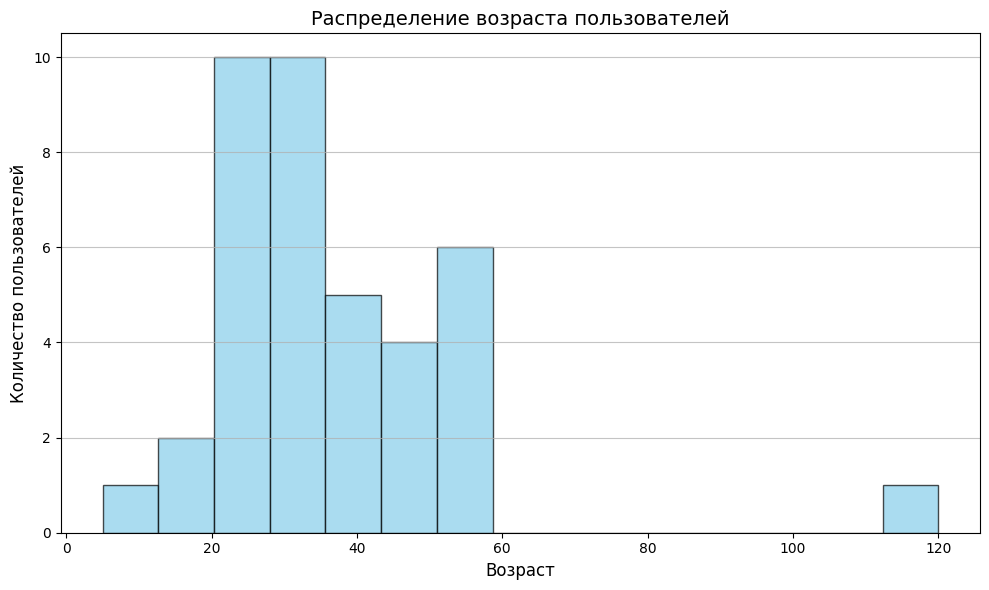

<Figure size 1000x600 with 0 Axes>

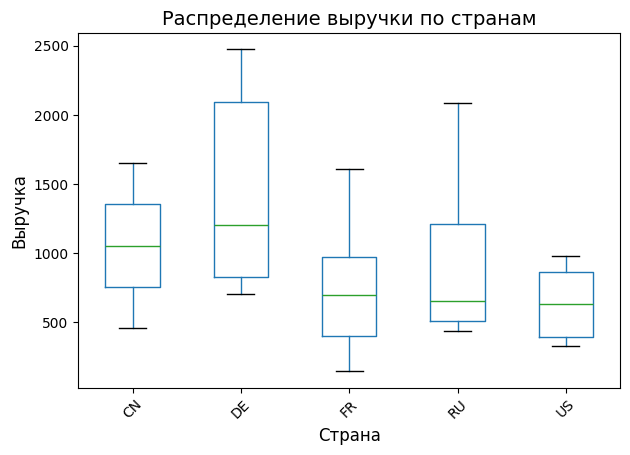

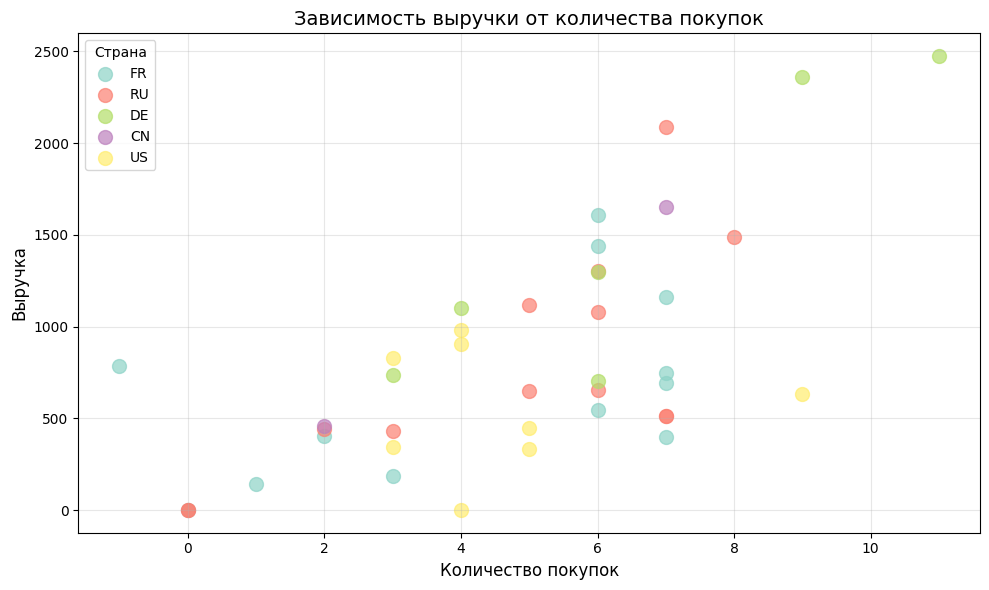

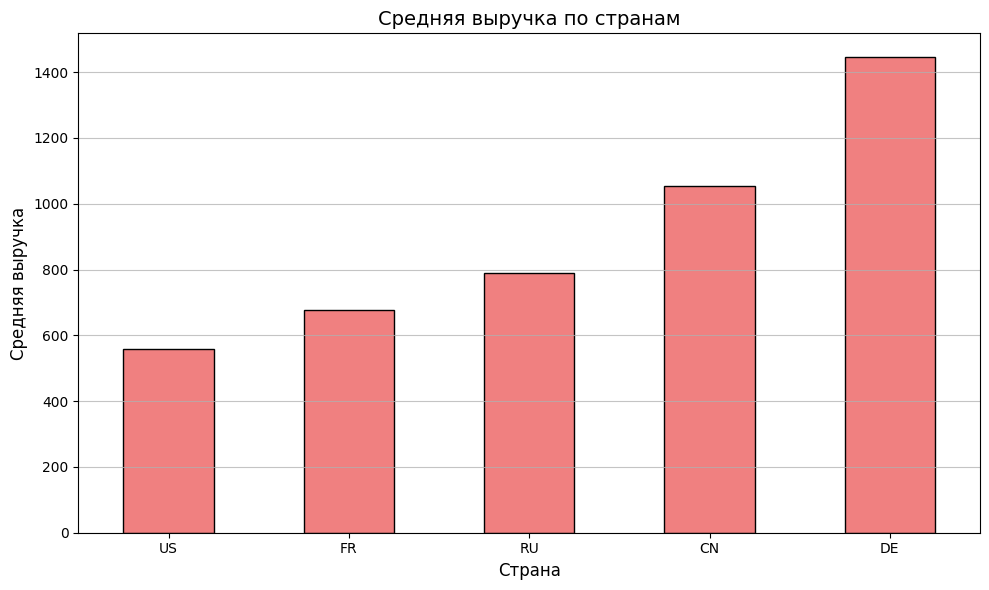

In [23]:
# Создаем папку для сохранения графиков
os.makedirs('figures', exist_ok=True)

# Гистограмма для количественного признака (возраст)
plt.figure(figsize=(10, 6))
plt.hist(df['age'].dropna(), bins=15, edgecolor='black', alpha=0.7, color='skyblue')
plt.title('Распределение возраста пользователей', fontsize=14)
plt.xlabel('Возраст', fontsize=12)
plt.ylabel('Количество пользователей', fontsize=12)
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.savefig('figures/age_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# Боксплот для количественного признака (выручка) по странам
plt.figure(figsize=(10, 6))
# Убираем выбросы для лучшей визуализации
df_filtered = df[df['revenue'] > 0]
df_filtered.boxplot(column='revenue', by='country', grid=False)
plt.title('Распределение выручки по странам', fontsize=14)
plt.suptitle('')  # Убираем автоматический заголовок
plt.xlabel('Страна', fontsize=12)
plt.ylabel('Выручка', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('figures/revenue_by_country_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

# Scatter plot для пары количественных признаков
plt.figure(figsize=(10, 6))

# Разные цвета для разных стран
countries = df['country'].unique()
colors = plt.cm.Set3(np.linspace(0, 1, len(countries)))

for i, country in enumerate(countries):
    country_data = df[df['country'] == country]
    plt.scatter(country_data['purchases'], country_data['revenue'],
               color=colors[i], alpha=0.7, s=100, label=country)

plt.title('Зависимость выручки от количества покупок', fontsize=14)
plt.xlabel('Количество покупок', fontsize=12)
plt.ylabel('Выручка', fontsize=12)
plt.legend(title='Страна')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/purchases_vs_revenue_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

# Дополнительный график: средняя выручка по странам
plt.figure(figsize=(10, 6))
mean_revenue_by_country = df.groupby('country')['revenue'].mean().sort_values()
mean_revenue_by_country.plot(kind='bar', color='lightcoral', edgecolor='black')
plt.title('Средняя выручка по странам', fontsize=14)
plt.xlabel('Страна', fontsize=12)
plt.ylabel('Средняя выручка', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.savefig('figures/mean_revenue_by_country.png', dpi=300, bbox_inches='tight')
plt.show()

# Гистограмма распределения возраста: Показывает, что большинство пользователей находятся в возрасте 20-45 лет, с пиком в районе 25-30 лет. Распределение имеет правый хвост с небольшим количеством пользователей старше 50 лет.

# Боксплот выручки по странам: Демонстрирует различия в распределении выручки между странами. Германия имеет самые высокие медианные значения выручки, в то время как США показывает наибольший разброс данных.

# Scatter plot зависимости выручки от количества покупок: Выявляет общую положительную корреляцию между количеством покупок и выручкой. Однако есть заметные выбросы - пользователи с малым количеством покупок, но высокой выручкой (вероятно, дорогие покупки), и наоборот.

# График средней выручки по странам: Наглядно показывает, что Германия лидирует по средней выручке на пользователя, за ней следуют Россия и Франция, в то время как США и Китай имеют более низкие показатели.
